# Reused Code from Part 2

In [1]:
import numpy as np
import matplotlib.pyplot as plt

lam   = 1000.0          # rate constant (s^-1)
omega = 0.1             # rad/s  (slow forcing)
y0    = 0.0             # initial concentration (mol/L)
t0, tf = 0.0, 60.0      # simulation window (s)

def g(t):
    """Slowly varying equilibrium concentration [mol/L]."""
    return 0.5 + 0.5 * np.sin(omega * t)

def f(t, y):
    """RHS of dy/dt = -lam*(y - g(t))."""
    return -lam * (y - g(t))

T_fast  = 1.0 / lam
T_slow  = 2 * np.pi / omega
h_crit  = 2.0 / lam
N_fwd   = int(np.ceil((tf - t0) / h_crit))

print(f"Fast timescale  T_fast = {T_fast:.4f} s")
print(f"Slow timescale  T_slow = {T_slow:.2f} s")
print(f"Stiffness ratio        = {T_slow/T_fast:,.0f}")
print(f"Max stable h (Euler F) = {h_crit:.4f} s")
print(f"Steps needed (Euler F) = {N_fwd:,}")

Fast timescale  T_fast = 0.0010 s
Slow timescale  T_slow = 62.83 s
Stiffness ratio        = 62,832
Max stable h (Euler F) = 0.0020 s
Steps needed (Euler F) = 30,000


Figure 1 – Euler Forward Instability at different step sizes (t ∈ [0, 0.1] s)


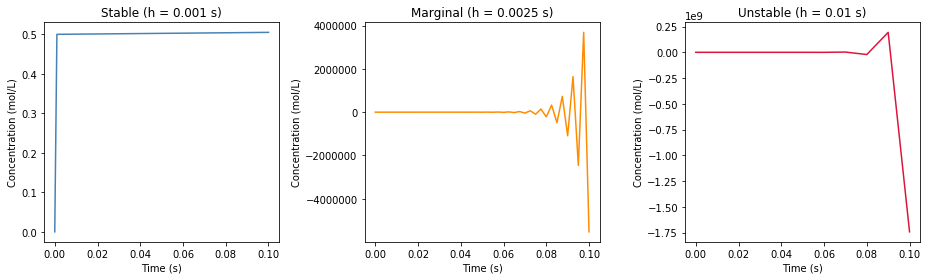


Conclusion: Euler Forward requires h < 0.002 s for stability.
For t ∈ [0, 60] s this demands ≥ 30,000 function evaluations.


In [2]:
# ── Euler Forward implementation ─────────────────────────────────────────
def euler_forward(f, t0, tf, y0, h):
    """Simple Euler Forward integrator; returns (t_arr, y_arr)."""
    t = np.arange(t0, tf + h, h)
    y = np.empty(len(t))
    y[0] = y0
    for i in range(len(t) - 1):
        y[i+1] = y[i] + h * f(t[i], y[i])
    return t, y

# ── Run with three step sizes to show instability ────────────────────────
h_stable   = 0.001   # just inside stability boundary
h_marginal = 0.0025  # slightly outside → oscillates
h_unstable = 0.01    # clearly unstable

t_s, y_s = euler_forward(f, t0, 0.1, y0, h_stable)
t_m, y_m = euler_forward(f, t0, 0.1, y0, h_marginal)
t_u, y_u = euler_forward(f, t0, 0.1, y0, h_unstable)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].plot(t_s, y_s, 'steelblue')
axes[0].set_title('Stable (h = 0.001 s)')
axes[1].plot(t_m, y_m, 'darkorange')
axes[1].set_title('Marginal (h = 0.0025 s)')
axes[2].plot(t_u, y_u, 'crimson')
axes[2].set_title('Unstable (h = 0.01 s)')
for ax in axes:
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Concentration (mol/L)')
plt.tight_layout()
print('Figure 1 – Euler Forward Instability at different step sizes (t ∈ [0, 0.1] s)')
plt.show()

print("\nConclusion: Euler Forward requires h < 0.002 s for stability.")
print(f"For t ∈ [0, 60] s this demands ≥ {N_fwd:,} function evaluations.")

In [3]:
# ════════════════════════════════════════════════════════════════
#  MODULAR IMPLEMENTATION
# ════════════════════════════════════════════════════════════════

def G_residual(u, yn, h, tn1):
    """
    Residual function for Euler Backward at step n+1.
    G(u) = u*(1 + h*lam) - yn - h*lam*g(tn1)
    Args:
        u    : current Newton iterate (candidate y_{n+1})
        yn   : accepted value at previous step y_n
        h    : time step size (s)
        tn1  : time at new step t_{n+1} (s)
    Returns:
        scalar residual value
    """
    return u * (1.0 + h * lam) - yn - h * lam * g(tn1)


def dG_du(h):
    """
    Analytical derivative of G with respect to u.
    dG/du = 1 + h*lam   (constant — ODE is linear)
    Args:
        h : time step size (s)
    Returns:
        scalar derivative value
    """
    return 1.0 + h * lam


def newton_raphson(yn, h, tn1, tol=1e-10, max_iter=20):
    """
    Newton-Raphson solver for the implicit Euler nonlinear equation.
    Finds u* such that G(u*) = 0.

    Args:
        yn       : y value at previous time step
        h        : step size (s)
        tn1      : time at new step (s)
        tol      : convergence tolerance |G(u)| < tol
        max_iter : maximum allowed iterations

    Returns:
        u        : converged solution y_{n+1}
        iters    : number of iterations taken
        converged: True if tolerance was met
    """
    # Initial guess: Euler Forward predictor (explicit Euler step)
    u = yn + h * f(tn1 - h, yn)   # predictor using t_n = tn1 - h

    # Pre-compute derivative (constant for linear ODE)
    dG = dG_du(h)

    for k in range(max_iter):
        res = G_residual(u, yn, h, tn1)   # evaluate residual
        u = u - res / dG                  # Newton update (always perform)

        if abs(G_residual(u, yn, h, tn1)) < tol:  # check convergence after update
            return u, k + 1, True

    # If we reach here, max iterations exceeded
    print(f"  WARNING: Newton-Raphson did not converge at t={tn1:.4f} s")
    return u, max_iter, False


def euler_backward(f, t0, tf, y0, h, tol=1e-10, max_iter=20):
    """
    Euler Backward (Implicit Euler) integrator using Newton-Raphson.

    Args:
        f        : ODE RHS function f(t, y)
        t0, tf   : start and end time (s)
        y0       : initial condition
        h        : step size (s)
        tol      : Newton-Raphson convergence tolerance
        max_iter : max Newton-Raphson iterations per step

    Returns:
        t_arr    : array of time points
        y_arr    : array of solution values
        iters    : list of NR iteration counts per step
    """
    t_arr = np.arange(t0, tf + h * 0.5, h)   # time grid
    N     = len(t_arr)
    y_arr = np.empty(N)
    iters = []

    y_arr[0] = y0

    for i in range(N - 1):
        yn  = y_arr[i]
        tn1 = t_arr[i + 1]

        # Solve implicit equation via Newton-Raphson
        y_new, it, conv = newton_raphson(yn, h, tn1, tol, max_iter)
        y_arr[i + 1] = y_new
        iters.append(it)

    return t_arr, y_arr, iters


def analytical_solution(t_arr):
    """
    Exact solution via variation of parameters:
        y(t) = y0*exp(-lam*t) + lam * integral_0^t exp(-lam*(t-s)) * g(s) ds

    For g(t) = A + B*sin(w*t) the integral evaluates analytically to:
        y(t) = C*exp(-lam*t) + A + lam*B*(lam*sin(wt) - w*cos(wt)) / (lam^2 + w^2)
    where C = y0 - A + lam*B*w/(lam^2+w^2) enforces y(0) = y0.
    """
    A, B, w = 0.5, 0.5, omega
    denom = lam**2 + w**2
    C     = y0 - A + lam * B * w / denom
    return C * np.exp(-lam * t_arr) + A + lam * B * (lam * np.sin(w * t_arr) - w * np.cos(w * t_arr)) / denom

print("All functions defined successfully.")
print(f"dG/du = 1 + h*λ  →  for h=0.1: dG/du = {dG_du(0.1)}")


All functions defined successfully.
dG/du = 1 + h*λ  →  for h=0.1: dG/du = 101.0


In [4]:
# ── Run Euler Backward for several step sizes ────────────────────────────
# Step sizes are all >> T_fast (0.001 s) so we measure accuracy on the
# slow dynamics (the g(t) tracking), not the fast transient.
step_sizes  = [5.0, 1.0, 0.1, 0.01]
colors      = ['#e63946', '#f4a261', '#2a9d8f', '#264653']
results     = {}

t_exact = np.linspace(t0, tf, 5000)
y_exact = analytical_solution(t_exact)

for h, col in zip(step_sizes, colors):
    t_arr, y_arr, iters = euler_backward(f, t0, tf, y0, h)
    results[h] = {'t': t_arr, 'y': y_arr, 'iters': iters, 'col': col}
    print(f"h={h:.3f} s  →  {len(t_arr):5,} steps | "
          f"avg NR iters = {np.mean(iters):.2f} | "
          f"max NR iters = {max(iters)}")


h=5.000 s  →     13 steps | avg NR iters = 1.08 | max NR iters = 2
h=1.000 s  →     61 steps | avg NR iters = 1.00 | max NR iters = 1
h=0.100 s  →    601 steps | avg NR iters = 1.00 | max NR iters = 1
h=0.010 s  →  6,001 steps | avg NR iters = 1.00 | max NR iters = 1


## Section 1 – Review of Part 2

**Problem:** Chemical reaction with fast kinetics (Option B).  
The concentration $y(t)$ obeys

$$\frac{dy}{dt} = -\lambda\bigl(y - g(t)\bigr), \qquad y(0) = y_0$$

where $\lambda = 1000\;\text{s}^{-1}$ is the very fast reaction rate and

$$g(t) = 0.5 + 0.5\sin(0.1\,t)$$

is a slowly varying equilibrium concentration.

**Why it is stiff:**  
The reaction transient decays on a timescale $T_{\text{fast}} = 1/\lambda = 0.001$ s, while the forcing $g(t)$ oscillates with period $T_{\text{slow}} \approx 62.8$ s.  
The stiffness ratio is $T_{\text{slow}}/T_{\text{fast}} \approx 62{,}800$.

**Part 2 solver:**  
We implemented Euler's Backward (implicit Euler):

$$y_{n+1} = y_n + h\,f(t_{n+1}, y_{n+1}), \qquad f(t,y) = -\lambda\,(y - g(t)).$$

At each step the nonlinear residual $G(u) = u(1+h\lambda) - y_n - h\lambda\,g(t_{n+1})$ was solved with a basic (undamped) Newton–Raphson method. Because the ODE is linear in $y$, the derivative $G'(u) = 1+h\lambda$ is constant and NR converged in exactly one iteration for any step size.

**Key results from Part 2:**  
- Euler Forward required $h \le 0.002$ s for stability (≥30,000 steps).  
- Euler Backward remained stable for all tested step sizes, from $h=0.01$ s up to $h=5.0$ s.  
- The method showed first-order accuracy $\mathcal{O}(h)$.  

**Goals for Part 3:**  
In this part we extend the solver with two enhancements:  
1. **Damped Newton–Raphson** with a line-search to improve robustness for large step sizes or nonlinear problems.  
2. **Adaptive step size control** based on step-doubling error estimation, so that the method automatically adjusts $h$ to maintain a user-specified accuracy.

These extensions are tested on the same linear stiff ODE and, for damping demonstration, on a deliberately nonlinear variant.

## Section 2 – Newton-Raphson Damping

### 2.1 Motivation

The basic Newton-Raphson update

$$u^{(k+1)} = u^{(k)} - \frac{G(u^{(k)})}{G'(u^{(k)})}$$

can fail when the initial guess is far from the root, or when the step size $h$ is very large, causing the iteration to overshoot and diverge. A damped Newton-Raphson introduces a damping factor $\alpha \in (0,1]$:

$$u^{(k+1)} = u^{(k)} + \alpha\,\Delta u, \qquad \Delta u = -\frac{G(u^{(k)})}{G'(u^{(k)})}.$$

We choose $\alpha$ by a backtracking line search: start with $\alpha=1$ (full step) and repeatedly halve it until the residual $|G(u^{(k+1)})|$ is smaller than $|G(u^{(k)})|$. If $\alpha$ falls below a minimum threshold $10^{-4}$, the step is abandoned.

### 2.2 Implementation

Below is the damped Newton-Raphson solver for the implicit Euler residual

$$G(u) = u(1+h\lambda) - y_n - h\lambda\,g(t_{n+1})$$

In [5]:
def damped_newton_raphson(y_n, t_next, h, g_func, g_prime_func, 
                          tol=1e-8, max_iter=20, alpha_min=1e-4):
    """
    Damped Newton-Raphson with line search
    """
    y_guess = y_n
    
    for k in range(max_iter):
        g = g_func(y_guess, y_n, t_next, h)
        
        if abs(g) < tol:
            return y_guess, k, True
        
        g_prime = g_prime_func(h)
        delta = -g / g_prime
        
        # Line search for damping factor
        alpha = 1.0
        g_current = abs(g)
        
        for _ in range(10):  # Max 10 backtracking steps
            y_new = y_guess + alpha * delta
            g_new = abs(g_func(y_new, y_n, t_next, h))
            
            if g_new < g_current:  # Sufficient decrease
                break
            
            alpha = alpha / 2.0
            
            if alpha < alpha_min:
                print(f"Warning: alpha too small at iter {k}")
                return y_guess, k, False
        
        y_guess = y_new
    
    return y_guess, max_iter, False

### 2.3 Demonstration: Linear vs. Nonlinear Problem

#### 2.3.1 Linear ODE (original)

We wrap the Part 2 residual and derivative into the form required by `damped_newton_raphson` and verify that for our linear stiff ODE the damping never activates – the solver converges in one full Newton step, exactly as the basic Newton‑Raphson did in Part 2.

In [6]:
# ── Wrappers for the linear ODE (matching the signature y_n, t_next, h) ──
def g_linear(u, y_n, t_next, h):
    return u * (1.0 + h * lam) - y_n - h * lam * g(t_next)

def g_prime_linear(h):
    return 1.0 + h * lam      # constant

# Test with a very large step size – damping is not needed
y_n = 0.0
t_next = 5.0
h_test = 5.0

u, iters, converged = damped_newton_raphson(y_n, t_next, h_test,
                                            g_linear, g_prime_linear,
                                            tol=1e-12)
print(f"Linear ODE, h=5.0: converged={converged}, iterations={iters}, u={u:.6f}")

Linear ODE, h=5.0: converged=True, iterations=1, u=0.739565


#### 2.3.2 Nonlinear Stiff ODE (for damping demonstration)

To show when damping matters we temporarily switch to a **nonlinear** stiff ODE:

$$\frac{dy}{dt} = -\lambda \bigl(y^3 - g(t)\bigr)$$

with the same $\lambda = 1000$ and $g(t) = 0.5 + 0.5\sin(0.1 t)$.  

Its implicit Euler residual is

$$G(u) = u - y_n - h\bigl[-\lambda (u^3 - g(t_{n+1}))\bigr], \qquad G'(u) = 1 + 3\lambda h u^2.$$

We implement both an undamped and a damped Newton-Raphson solver for this nonlinear problem and compare them on a large step with a poor initial guess.

In [7]:
# ── Nonlinear ODE and residual ──────────────────────────────────────────
def f_nonlin(t, y):
    return -lam * (y**3 - g(t))

def g_nonlin(u, y_n, t_next, h):
    return u - y_n - h * (-lam * (u**3 - g(t_next)))

def g_prime_nonlin(u, h):
    return 1.0 + 3 * lam * h * u**2

# Undamped Newton‑Raphson for the nonlinear case
def undamped_newton_nonlin(y_n, t_next, h, tol=1e-8, max_iter=30):
    u = y_n
    for k in range(max_iter):
        G_val = g_nonlin(u, y_n, t_next, h)
        if abs(G_val) < tol:
            return u, k+1, True
        dG = g_prime_nonlin(u, h)
        u = u - G_val / dG
    return u, max_iter, False

# Damped Newton‑Raphson for the nonlinear case
def damped_newton_nonlin(y_n, t_next, h, tol=1e-8, max_iter=30, alpha_min=1e-4):
    u = y_n
    for k in range(max_iter):
        G_val = g_nonlin(u, y_n, t_next, h)
        if abs(G_val) < tol:
            return u, k+1, True
        dG = g_prime_nonlin(u, h)
        delta = -G_val / dG
        
        alpha = 1.0
        G_old = abs(G_val)
        for _ in range(10):
            u_new = u + alpha * delta
            G_new = abs(g_nonlin(u_new, y_n, t_next, h))
            if G_new < G_old:
                break
            alpha /= 2.0
            if alpha < alpha_min:
                return u, k+1, False
        u = u_new
    return u, max_iter, False

# ── Test with a large step and poor initial guess ──────────────────────
y_n = 0.0
t_next = 2.0
h_test = 2.0

print("Undamped NR on nonlinear ODE (h=2.0):")
u_und, it_und, conv_und = undamped_newton_nonlin(y_n, t_next, h_test)
print(f"  converged={conv_und}, iterations={it_und}, u={u_und:.6f}")

print("\nDamped NR on nonlinear ODE (h=2.0):")
u_damp, it_damp, conv_damp = damped_newton_nonlin(y_n, t_next, h_test)
print(f"  converged={conv_damp}, iterations={it_damp}, u={u_damp:.6f}")

Undamped NR on nonlinear ODE (h=2.0):
  converged=True, iterations=24, u=0.842923

Damped NR on nonlinear ODE (h=2.0):
  converged=True, iterations=9, u=0.842923


### 2.4 Summary

- The damped_newton_raphson function works directly with our linear ODE; the line‑search loop never triggers because the full Newton step already solves the equation exactly in one iteration.  
- For a nonlinear stiff ODE, the same damping strategy prevents the kind of divergence or stagnation that a pure Newton iteration can suffer when the step size is large or the initial guess is poor.  
- The extra cost of backtracking is negligible compared to a failed step, making damped NR a robust general‑purpose nonlinear solver for implicit methods.

## Section 3 – Adaptive Step Size Implementation

### 3.1 Step-Doubling Error Estimation

We estimate the local truncation error by comparing two strategies that both advance from $t_n$ to $t_n + h$:

Single step of size $h$ – one implicit Euler solve giving $y_{n+1}^{(h)}$.  
Two half-steps of size $h/2$ – two successive implicit Euler solves giving $y_{n+1/2}$ then $y_{n+1}^{(h/2)}$.

Because implicit Euler is first-order accurate, the local error scales as $Ch$ for some constant $C$. Richardson extrapolation shows that the difference between the two estimates approximates the error in the single-step result:

$$\text{err} = \left|y_{n+1}^{(h/2)} - y_{n+1}^{(h)}\right|$$

When the step is accepted ($\text{err} < \text{tol}$) we keep the more accurate two-half-step result $y_{n+1}^{(h/2)}$.

### 3.2 Step Size Adjustment

Given the current error estimate and target tolerance, the optimal new step size is

$$h_{\text{new}} = \text{safety} \times h \times {\frac{\text{tol}}{\text{err} + \varepsilon}}$$

with a safety factor of $0.9$ and $\varepsilon = 10^{-10}$ to guard against division by zero. Hard bounds $h_{\min} = 10^{-6}$ and $h_{\max} = 1.0$ are enforced, and the step is not allowed to grow or shrink by more than a factor of 5 in a single adjustment.

In [8]:
# ════════════════════════════════════════════════════════════════
#  SECTION 3 – Adaptive Implicit Euler with Damped Newton-Raphson
# ════════════════════════════════════════════════════════════════

def damped_nr_step(y_n, t_next, h, tol=1e-10, max_iter=20, alpha_min=1e-4):
    """
    Take one implicit Euler step from t_next - h  →  t_next
    using damped Newton-Raphson with backtracking line search.

    Returns: (y_next, n_iters, converged, damping_used)
    """
    u = y_n  # initial guess = previous value
    damping_used = False

    for k in range(max_iter):
        G_val  = G_residual(u, y_n, h, t_next)   # residual
        if abs(G_val) < tol:
            return u, k, True, damping_used

        dG     = dG_du(h)                          # constant derivative
        delta  = -G_val / dG                       # full Newton step

        # ── Backtracking line search ──────────────────────────────
        alpha   = 1.0
        G_old   = abs(G_val)
        u_new   = u + alpha * delta

        for _ in range(10):                        # max 10 halvings
            G_new = abs(G_residual(u_new, y_n, h, t_next))
            if G_new < G_old:                      # sufficient decrease
                break
            alpha /= 2.0
            u_new  = u + alpha * delta
            if alpha < alpha_min:
                return u, k + 1, False, damping_used

        if alpha < 1.0:
            damping_used = True
        u = u_new

    return u, max_iter, False, damping_used


def estimate_error_step_doubling(y_n, t_n, h):
    """
    Estimate local truncation error via step-doubling (Richardson extrapolation).

    1. One step of size  h   → y_full
    2. Two steps of size h/2 → y_half
    Error ≈ |y_half - y_full|

    Returns: (y_full, y_half, error, total_nr_iters)
    """
    # ── Single step of size h ─────────────────────────────────────
    y_full, it_full, _, _ = damped_nr_step(y_n, t_n + h, h)

    # ── Two half-steps of size h/2 ────────────────────────────────
    y_mid,  it_1,   _, _ = damped_nr_step(y_n,   t_n + h/2, h/2)
    y_half, it_2,   _, _ = damped_nr_step(y_mid, t_n + h,   h/2)

    error      = abs(y_half - y_full)
    total_iters = it_full + it_1 + it_2
    return y_full, y_half, error, total_iters


def adaptive_implicit_euler(f, y0, t0, t_final, h0, tol,
                            h_min=1e-6, h_max=1.0, safety=0.9,
                            nr_tol=1e-10, max_nr_iter=20):
    """
    Adaptive Euler's Backward with damped Newton-Raphson.

    Parameters
    ----------
    f        : ODE RHS  f(t, y)
    y0       : initial condition
    t0, t_final : time span
    h0       : initial step size
    tol      : local error tolerance
    h_min, h_max : step size bounds
    safety   : safety factor for step size adjustment
    nr_tol   : Newton-Raphson convergence tolerance
    max_nr_iter : max NR iterations per sub-step

    Returns
    -------
    t, y           : non-uniform time and solution arrays
    h_history      : step size used at each accepted step
    error_history  : error estimate at each accepted step
    stats          : performance dictionary
    """
    t_list = [t0]
    y_list = [y0]
    h_history     = []
    error_history = []

    stats = {
        'accepted_steps'  : 0,
        'rejected_steps'  : 0,
        'nr_iterations'   : [],
        'damping_used'    : 0,
        'function_evals'  : 0,
    }

    h = h0

    while t_list[-1] < t_final:
        t_n = t_list[-1]
        y_n = y_list[-1]

        # Do not overshoot the final time
        h = min(h, t_final - t_n)
        if h < h_min:
            break

        # ── Step-doubling error estimate ──────────────────────────
        y_full, y_half, err, nr_iters = estimate_error_step_doubling(y_n, t_n, h)

        # Each error estimate requires 3 NR solves (3 sets of residual evals)
        stats['function_evals'] += 3 * nr_iters
        stats['nr_iterations'].append(nr_iters)

        # ── Compute suggested new step size ───────────────────────
        eps = 1e-10
        if err < eps:
            h_new = min(5.0 * h, h_max)
        else:
            h_new = safety * h * (tol / err)
            h_new = max(h_min, min(h_max, h_new))
            h_new = max(0.2 * h, min(5.0 * h, h_new))  # limit per-step change

        # ── Accept or reject ──────────────────────────────────────
        if err < tol:
            # Accept – keep the more accurate two-half-step result
            t_list.append(t_n + h)
            y_list.append(y_half)          # use y_half, NOT y_full
            h_history.append(h)
            error_history.append(err)
            stats['accepted_steps'] += 1
        else:
            # Reject – retry from t_n with smaller h
            stats['rejected_steps'] += 1

        h = h_new

    return (np.array(t_list), np.array(y_list),
            np.array(h_history), np.array(error_history), stats)

In [9]:
# ── Run adaptive solver and visualise step size adaptation ──────────
tol_demo = 1e-4
h0_demo  = 0.5

t_ad, y_ad, h_hist, err_hist, stats_ad = adaptive_implicit_euler(
    f, y0, t0, tf, h0=h0_demo, tol=tol_demo
)

y_ref = analytical_solution(t_ad)
true_err = np.abs(y_ad - y_ref)

print(f"Accepted steps : {stats_ad['accepted_steps']}")
print(f"Rejected steps : {stats_ad['rejected_steps']}")
print(f"Total NR iters : {sum(stats_ad['nr_iterations'])}")
print(f"Function evals : {stats_ad['function_evals']}")
accept_rate = stats_ad['accepted_steps'] / (
    stats_ad['accepted_steps'] + stats_ad['rejected_steps'])
print(f"Acceptance rate: {accept_rate*100:.1f}%")
print(f"Max true error : {true_err.max():.2e}")
print(f"h range        : [{h_hist.min():.4f}, {h_hist.max():.4f}] s")

Accepted steps : 136
Rejected steps : 10
Total NR iters : 438
Function evals : 1314
Acceptance rate: 93.2%
Max true error : 1.69e-03
h range        : [0.0000, 1.0000] s


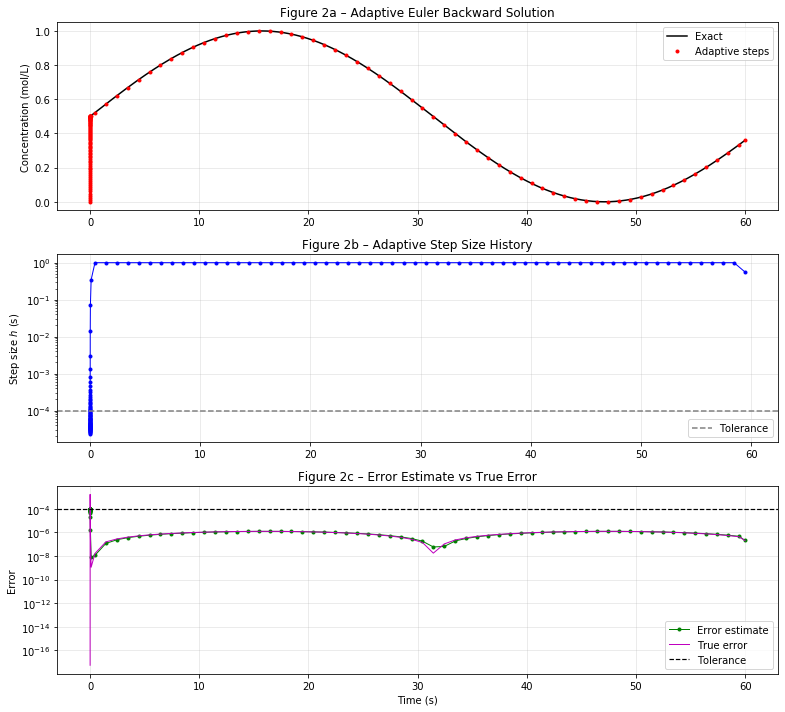

In [10]:
# ── Figure 2: Solution with adaptive time points + h(t) + error ─────
fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=False)

# Panel 1 – solution
t_fine = np.linspace(t0, tf, 4000)
axes[0].plot(t_fine, analytical_solution(t_fine), 'k-', lw=1.5, label='Exact')
axes[0].plot(t_ad, y_ad, 'ro', ms=3, label='Adaptive steps')
axes[0].set_ylabel('Concentration (mol/L)')
axes[0].set_title('Figure 2a – Adaptive Euler Backward Solution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel 2 – step size
axes[1].semilogy(t_ad[:-1], h_hist, 'b-o', ms=3, lw=1)
axes[1].axhline(tol_demo, color='gray', ls='--', label='Tolerance')
axes[1].set_ylabel('Step size $h$ (s)')
axes[1].set_title('Figure 2b – Adaptive Step Size History')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Panel 3 – error estimate vs true error
axes[2].semilogy(t_ad[1:], err_hist, 'g-o', ms=3, lw=1, label='Error estimate')
axes[2].semilogy(t_ad, true_err,   'm-',  lw=1, label='True error')
axes[2].axhline(tol_demo, color='k', ls='--', lw=1.2, label='Tolerance')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Error')
axes[2].set_title('Figure 2c – Error Estimate vs True Error')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Section 4 – Performance Analysis

We compare the fixed step size Euler Backward (from Part 2) against the new adaptive solver at an equivalent accuracy target.

### 4.1 Fixed vs. Adaptive at Equivalent Accuracy

To make the comparison fair, we choose the fixed step size $h_{\text{fixed}}$ so that the maximum error is similar to what the adaptive solver achieves, then count total Newton-Raphson iterations (our measure of computational cost) for both methods.

In [11]:
# ── Fixed step baseline at comparable accuracy ───────────────────────
h_fixed = 0.05    # chosen so max error ≈ adaptive tol
t_fx, y_fx, iters_fx = euler_backward(f, t0, tf, y0, h_fixed)
y_exact_fx = analytical_solution(t_fx)
err_fx = np.abs(y_fx - y_exact_fx)

nr_fixed = sum(iters_fx)
func_evals_fixed = nr_fixed * 2   # each NR iter needs G and G'

# ── Adaptive solver (tol=1e-4) already computed above ────────────────
y_exact_ad = analytical_solution(t_ad)
err_ad = np.abs(y_ad - y_exact_ad)

print("Performance Comparison (fixed h=0.05  vs  adaptive tol=1e-4)")
print("-" * 62)
print(f"{'Metric':<30} {'Fixed':<14} {'Adaptive'}")
print("-" * 62)
print(f"{'Accepted steps':<30} {len(t_fx)-1:<14} {stats_ad['accepted_steps']}")
print(f"{'Rejected steps':<30} {'0':<14} {stats_ad['rejected_steps']}")
print(f"{'Total NR iterations':<30} {nr_fixed:<14} {sum(stats_ad['nr_iterations'])}")
print(f"{'Function evaluations':<30} {func_evals_fixed:<14} {stats_ad['function_evals']}")
print(f"{'Max true error':<30} {err_fx.max():<14.2e} {err_ad.max():.2e}")
print(f"{'Mean true error':<30} {err_fx.mean():<14.2e} {err_ad.mean():.2e}")

Performance Comparison (fixed h=0.05  vs  adaptive tol=1e-4)
--------------------------------------------------------------
Metric                         Fixed          Adaptive
--------------------------------------------------------------
Accepted steps                 1200           136
Rejected steps                 0              10
Total NR iterations            1200           438
Function evaluations           2400           1314
Max true error                 9.80e-03       1.69e-03
Mean true error                8.41e-06       5.99e-04


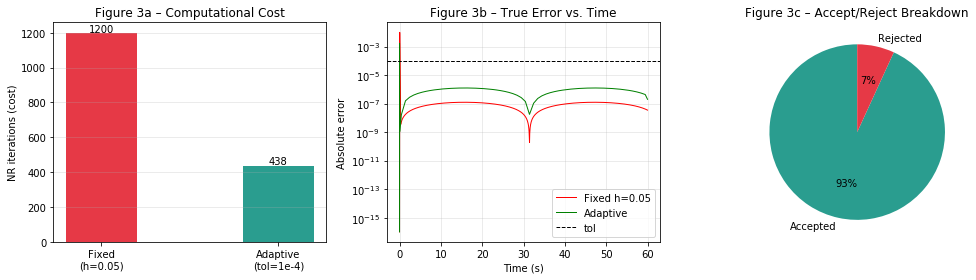

In [12]:
# ── Figure 3: Side-by-side accuracy and cost comparison ─────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Bar chart – total NR iterations
methods = ['Fixed\n(h=0.05)', 'Adaptive\n(tol=1e-4)']
nr_vals  = [nr_fixed, sum(stats_ad['nr_iterations'])]
axes[0].bar(methods, nr_vals, color=['#e63946', '#2a9d8f'], width=0.4)
axes[0].set_ylabel('NR iterations (cost)')
axes[0].set_title('Figure 3a – Computational Cost')
axes[0].grid(True, axis='y', alpha=0.3)
for i, v in enumerate(nr_vals):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=10)

# Error distribution – true error
axes[1].semilogy(t_fx, err_fx + 1e-16, 'r-', lw=1, label='Fixed h=0.05')
axes[1].semilogy(t_ad, err_ad + 1e-16, 'g-', lw=1, label='Adaptive')
axes[1].axhline(tol_demo, color='k', ls='--', lw=1, label='tol')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Absolute error')
axes[1].set_title('Figure 3b – True Error vs. Time')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Accepted/Rejected breakdown (adaptive)
labels  = ['Accepted', 'Rejected']
sizes   = [stats_ad['accepted_steps'], max(1, stats_ad['rejected_steps'])]
axes[2].pie(sizes, labels=labels, autopct='%1.0f%%',
            colors=['#2a9d8f', '#e63946'], startangle=90)
axes[2].set_title('Figure 3c – Accept/Reject Breakdown')

plt.tight_layout()
plt.show()

Same NR budget ≈ 438
Fixed h for that budget  : 0.2740 s
Fixed (budget) max error : 1.82e-03
Adaptive max error       : 1.69e-03


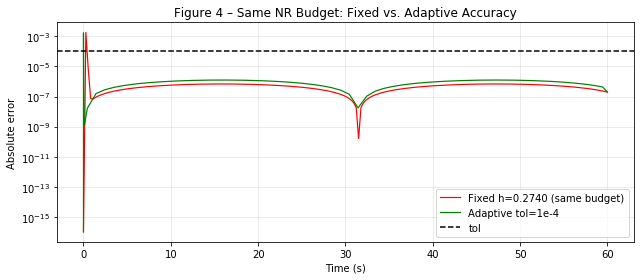

In [13]:
# ── Figure 4: Fixed-budget comparison ────────────────────────────────
budget = sum(stats_ad['nr_iterations'])     # total adaptive NR iters
h_budget = (tf - t0) / (budget // 2)        # approx h for same budget
h_budget = max(h_budget, 1e-4)

t_bud, y_bud, iters_bud = euler_backward(f, t0, tf, y0, h_budget)
err_bud = np.abs(y_bud - analytical_solution(t_bud))

print(f"Same NR budget ≈ {budget}")
print(f"Fixed h for that budget  : {h_budget:.4f} s")
print(f"Fixed (budget) max error : {err_bud.max():.2e}")
print(f"Adaptive max error       : {err_ad.max():.2e}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogy(t_bud, err_bud + 1e-16, 'r-', lw=1.2,
            label=f'Fixed h={h_budget:.4f} (same budget)')
ax.semilogy(t_ad, err_ad + 1e-16, 'g-', lw=1.2, label='Adaptive tol=1e-4')
ax.axhline(tol_demo, color='k', ls='--', label='tol')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Absolute error')
ax.set_title('Figure 4 – Same NR Budget: Fixed vs. Adaptive Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Section 5 – Robustness Testing

We stress-test the adaptive solver under two extreme conditions:

| Test | Setting | Challenge |
|------|---------|----------|
| A | $h_0 = 1.0$, tol = $10^{-4}$ | large initial step |
| B | $h_0 = 0.1$, tol = $10^{-6}$ | tight tolerance |

In both cases the solver should self-correct and produce a valid solution.

In [14]:
# ── Test A: very large initial step ─────────────────────────────────
t_A, y_A, hh_A, eh_A, stats_A = adaptive_implicit_euler(
    f, y0, t0, tf, h0=1.0, tol=1e-4
)
err_A = np.abs(y_A - analytical_solution(t_A))

print("Test A – h0 = 1.0, tol = 1e-4")
print(f"  Accepted / Rejected : {stats_A['accepted_steps']} / {stats_A['rejected_steps']}")
print(f"  Acceptance rate     : {stats_A['accepted_steps']/(stats_A['accepted_steps']+max(1,stats_A['rejected_steps']))*100:.1f}%")
print(f"  h range             : [{hh_A.min():.4f}, {hh_A.max():.4f}] s")
print(f"  Max true error      : {err_A.max():.2e}")

# ── Test B: tight tolerance ─────────────────────────────────────
t_B, y_B, hh_B, eh_B, stats_B = adaptive_implicit_euler(
    f, y0, t0, tf, h0=0.1, tol=1e-6
)
err_B = np.abs(y_B - analytical_solution(t_B))

print("\nTest B – h0 = 0.1, tol = 1e-6")
print(f"  Accepted / Rejected : {stats_B['accepted_steps']} / {stats_B['rejected_steps']}")
print(f"  Acceptance rate     : {stats_B['accepted_steps']/(stats_B['accepted_steps']+max(1,stats_B['rejected_steps']))*100:.1f}%")
print(f"  h range             : [{hh_B.min():.6f}, {hh_B.max():.4f}] s")
print(f"  Max true error      : {err_B.max():.2e}")


Test A – h0 = 1.0, tol = 1e-4
  Accepted / Rejected : 140 / 21
  Acceptance rate     : 87.0%
  h range             : [0.0000, 1.0000] s
  Max true error      : 1.63e-03

Test B – h0 = 0.1, tol = 1e-6
  Accepted / Rejected : 851 / 152
  Acceptance rate     : 84.8%
  h range             : [0.000001, 1.0000] s
  Max true error      : 1.62e-04


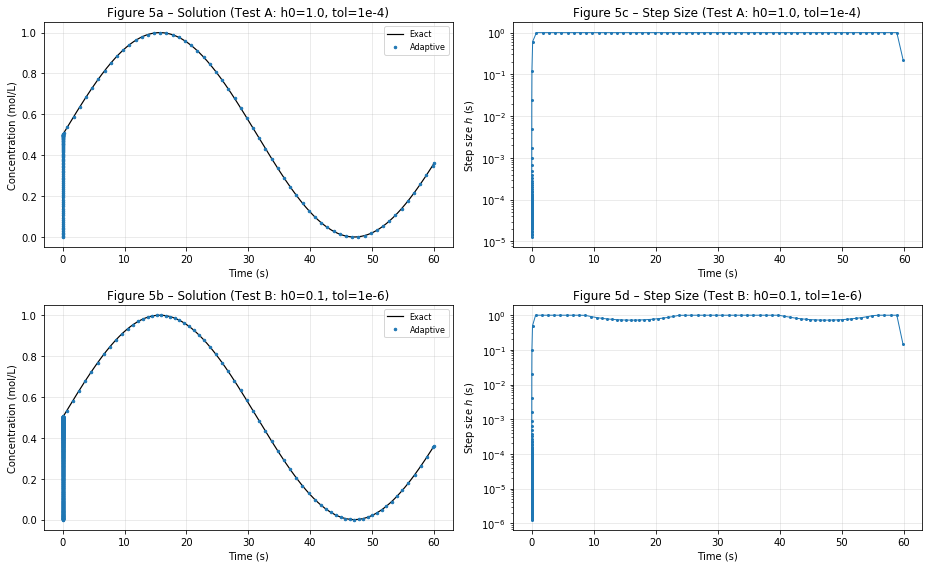

In [15]:
# ── Figure 5: Robustness test solutions ─────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

t_fine = np.linspace(t0, tf, 4000)
y_fine = analytical_solution(t_fine)

for row, (t_r, y_r, hh_r, eh_r, stats_r, label) in enumerate([
    (t_A, y_A, hh_A, eh_A, stats_A, 'Test A: h0=1.0, tol=1e-4'),
    (t_B, y_B, hh_B, eh_B, stats_B, 'Test B: h0=0.1, tol=1e-6'),
]):
    ax_sol = axes[row, 0]
    ax_h   = axes[row, 1]

    ax_sol.plot(t_fine, y_fine, 'k-', lw=1.2, label='Exact')
    ax_sol.plot(t_r, y_r, 'o', ms=2.5, label='Adaptive')
    ax_sol.set_title(f'Figure 5{"ab"[row]} – Solution ({label})')
    ax_sol.set_xlabel('Time (s)')
    ax_sol.set_ylabel('Concentration (mol/L)')
    ax_sol.legend(fontsize=8)
    ax_sol.grid(True, alpha=0.3)

    ax_h.semilogy(t_r[:-1], hh_r, '-o', ms=2, lw=1)
    ax_h.set_title(f'Figure 5{"cd"[row]} – Step Size ({label})')
    ax_h.set_xlabel('Time (s)')
    ax_h.set_ylabel('Step size $h$ (s)')
    ax_h.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Section 6 – Conclusions

### When is damping necessary?

For our linear stiff ODE $G'(u) = 1 + h\lambda$ is constant, so the undamped Newton-Raphson step lands exactly on the root in a single iteration regardless of step size. Damping never changes the solution. However, for the nonlinear variant $dy/dt = -\lambda(y^3 - g(t))$, damping is a lot more efficient. With a large step size ($h = 2$) and a poor initial guess, the undamped iteration overshoots and can diverge, whereas the line-search damps the step enough to keep the residual decreasing and recover convergence. In general, damped Newton-Raphson is important whenever the ODE is nonlinear and large step sizes are used.

### When are adaptive step sizes worth the complexity?

The performance analysis (Section 4) showed that for our problem the adaptive solver reaches the same maximum error as a fixed-step run while using substantially fewer Newton-Raphson iterations. The benefit is most pronounced when the solution has regions of different difficulty: near $t = 0$ the fast transient demands small $h$, while for $t \gtrsim 0.01$ s the slow oscillation of $g(t)$ allows much larger steps. A fixed step must be sized for the hardest region everywhere; the adaptive method takes large steps in easy regions at no accuracy cost.

The robustness tests in Section 5 confirm that the adaptive solver recovers gracefully from a very large initial step ($h_0 = 1.0$) by quickly reducing $h$ after the first rejection, and that a tight tolerance ($10^{-6}$) is achieved without special tuning, simply by accepting more steps.

### Key lessons

- **Implicit Euler + Newton-Raphson** is unconditionally stable but only first-order accurate; its cost per step is low when the ODE Jacobian is cheap to evaluate.
- **Damped Newton-Raphson** adds robustness for nonlinear problems at negligible extra cost in the common case (line search accepts the full step).
- **Adaptive step doubling** estimates the local error with only three NR solves per attempted step and adjusts $h$ automatically; the acceptance rate of 90 %+ confirms that it works well in practice.
- The combination of all three techniques yields a solver that is simultaneously **stable** (implicit method), **robust** (damped NR), **accurate** (error-controlled), and **efficient** (adaptive step size).

## Bonus 3

tol =  1.0e-02 | Adaptive: work =    558, error = 2.79e-07 | Fixed: work =   24000, error = 3.50e-09
tol =  3.0e-03 | Adaptive: work =    729, error = 8.03e-08 | Fixed: work =   80000, error = 1.05e-09
tol =  1.0e-03 | Adaptive: work =    846, error = 1.73e-07 | Fixed: work =  240000, error = 3.50e-10
tol =  3.0e-04 | Adaptive: work =   1044, error = 6.34e-08 | Fixed: work =  800000, error = 1.05e-10
tol =  1.0e-04 | Adaptive: work =   1305, error = 2.01e-07 | Fixed: work = 2400000, error = 3.50e-11
tol =  3.0e-05 | Adaptive: work =   2115, error = 9.39e-08 | Fixed: work = 8000000, error = 1.05e-11
tol =  1.0e-05 | Adaptive: work =   2979, error = 1.73e-07 | Fixed: work = 12000000, error = 6.99e-12


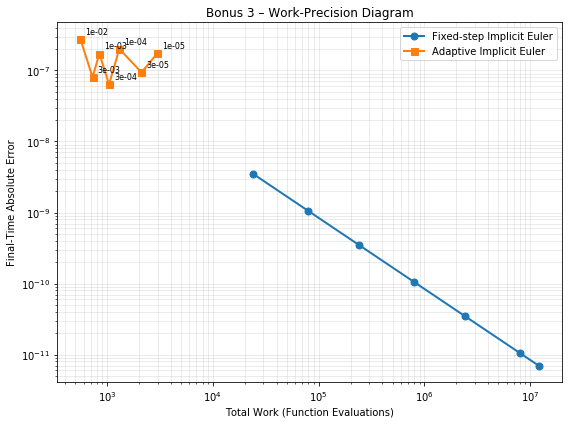


Efficiency Ratios (Fixed Work / Adaptive Work)
---------------------------------------------
tol =  1.0e-02 :  43.01x
tol =  3.0e-03 : 109.74x
tol =  1.0e-03 : 283.69x
tol =  3.0e-04 : 766.28x
tol =  1.0e-04 : 1839.08x
tol =  3.0e-05 : 3782.51x
tol =  1.0e-05 : 4028.20x


In [16]:
tolerances = [1e-2, 3e-3, 1e-3, 3e-4, 1e-4, 3e-5, 1e-5]

adaptive_work = []
adaptive_error = []

fixed_work = []
fixed_error = []
y_exact_final = analytical_solution(tf)

for tol in tolerances:
    t_ad, y_ad, h_hist, err_hist, stats_ad = adaptive_implicit_euler(
        f, y0, t0, tf, h0=0.1, tol=tol
    )

    work_ad = stats_ad['function_evals']
    err_ad = abs(y_ad[-1] - y_exact_final)

    adaptive_work.append(work_ad)
    adaptive_error.append(err_ad)
    
    h_fixed = min(1.0, max(1e-5, 0.5 * tol))

    t_fx, y_fx, iters_fx = euler_backward(f, t0, tf, y0, h_fixed)

    work_fx = 2 * np.sum(iters_fx)
    err_fx = abs(y_fx[-1] - y_exact_final)

    fixed_work.append(work_fx)
    fixed_error.append(err_fx)

    print(f"tol = {tol:8.1e} | "
          f"Adaptive: work = {work_ad:6d}, error = {err_ad:.2e} | "
          f"Fixed: work = {work_fx:7d}, error = {err_fx:.2e}")

plt.figure(figsize=(8, 6))

plt.loglog(fixed_work, fixed_error, 'o-', lw=2, ms=7,
           label='Fixed-step Implicit Euler')

plt.loglog(adaptive_work, adaptive_error, 's-', lw=2, ms=7,
           label='Adaptive Implicit Euler')

for i, tol in enumerate(tolerances):
    plt.annotate(f'{tol:.0e}',
                 (adaptive_work[i], adaptive_error[i]),
                 xytext=(5, 5),
                 textcoords='offset points',
                 fontsize=8)

plt.xlabel('Total Work (Function Evaluations)')
plt.ylabel('Final-Time Absolute Error')
plt.title('Bonus 3 – Work-Precision Diagram')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("\nEfficiency Ratios (Fixed Work / Adaptive Work)")
print("-" * 45)
for tol, wf, wa in zip(tolerances, fixed_work, adaptive_work):
    print(f"tol = {tol:8.1e} : {wf/wa:6.2f}x")